# <img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 6

Autor: Lopez Cruz Juan Carlos.

# Introducción

A continuación se muestran 2 circuitos conocidos en un esquema de 3 nodos externos. Tener en cuenta que para el análisis de la red se pueden definir nodos internos.

# <img src="./circuitos_ts6.png" /> 

## Items a tratar de las redes:

1. Construir la ***Matriz Admitancia Indefinida*** para cada caso. En el **BS170** plantear el modelo lineal visto en clase con admitancias y generadores de corriente, que tenga en cuenta: $C_{iss}$, $C_{oss}$, $C_{rss}$ y $g_m$

2. Para la red T se pide:
   
   a ) Obtener $\frac{V_{23}}{V_{13}}$ ; $\frac{V_{21}}{V_{31}}$ y $\frac{V_{12}}{V_{32}}$, explicitando el armado de los cofactores de segundo orden.
   
   b ) Graficar y observar detenidamente la respuesta de módulo y fase para cada transferencia. Analizar si entre 2 de las transferencias halladas se cumple que son complementarias en módulo : $|T_a + T_b| = 1$

3. Para el MOS se pide:
   
   a ) Dada la MAI hallada en 1 obtener los parámetros $Y$ para las configuraciones *source común* y *drain común*.
   
   b ) Calcular la matriz de parámetros $ABCD$ en configuración source común.

Propiedades de la *MAI*:

* La sumatoria de filas es igual a cero.
* La sumatoria de columnas es igual a cero.
* El determinante de la matriz es igual a cero.
* Todos los cofactores de primer orden son iguales, es decir: $Y_j^i = Y_m^n$

## Items Bonus(aun no estan hechos, estan en proceso)

1. Implementar en Python el armado de la MAI y la obtención de 2a) con los módulos disponibles en pytc2

2. Simulación Circuital y medición de los parámetros $Y$ del MOS en configuración drain común. Implementar el modelo SPICE del *BS170*:

## Resolucion:

### MAI de la red T

La MAI de esta red T es la siguiente.

$$Y_{MAI} = \begin{pmatrix}
\frac{1}{sL} & 0 & 0 & -\frac{1}{sL} \\
0 & \frac{1}{sL} & 0 & -\frac{1}{sL} \\
0 & 0 & sC & -sC \\
-\frac{1}{sL} & -\frac{1}{sL} & -sC & \frac{2}{sL} + sC
\end{pmatrix}$$

### Obtencion de las transferencias mediante cofactores de segundo orden

La relación general de transferencia mediante la MAI es:

$$T = \frac{V_{jk}}{V_{mn}} = (-1)^{(j+k+m+n)} \frac{Y_{mn}^{jk}}{Y_{mn}^{mn}}$$

Donde $Y_{mn}^{jk}$ representa el cofactor de segundo orden al eliminar filas $j, m$ y columnas $k, n$ y $(-1)^{(j+k+m+n)}$ representa nuestra funcion de correcion, en caso de no pueda corregir la funcion usamos la siguiente funcion de correcion $sgn(j - k) \cdot sgn(m - n)$, ademas de para nuestra resolucion optaremos para resolverlo mediante admitancia generica donde $\frac{1}{sL} = Y_L$ y $sC = Y_C$ con el fin de poder verificar nuestros resultados mediante python.

#### 1. Transferencia $\frac{V_{23}}{V_{13}}$

* **Entrada:** entre nodo 1 y nodo 3 ($V_{13} \rightarrow m=1, n=3$).
* **Salida:** entre nodo 2 y nodo 3 ($V_{23} \rightarrow j=2, k=3$).

**Denominador: Cofactor $Y_{13}^{13}$**

Eliminando filas (1, 3) y columnas (1, 3) de $Y_{4\times 4}$:

$$Y_{13}^{13} = (-1)^{(1+3+1+3)} \det \begin{pmatrix}
Y_L & -Y_L \\
-Y_L & 2Y_L + Y_C
\end{pmatrix}
= 1 \cdot Y_L \cdot (2Y_L + Y_C) -[(-Y_L) \cdot (-Y_L)] = 2Y_L^2 + Y_L \cdot Y_C - Y_L^2 = Y_L^2 + Y_L \cdot Y_C$$

**Numerador: Cofactor $Y_{13}^{23}$**

Eliminando filas (2, 3) y columnas (1, 3) de $Y_{4\times 4}$:

$$Y_{13}^{23} = (-1)^{(1+3+2+3)} \det \begin{pmatrix}
0 & -Y_L \\
-Y_L & 2Y_L + Y_C
\end{pmatrix} = -1 \cdot [0 - (-Y_L) \cdot (-Y_L)] = Y_L^2$$

**Transferencia final:**

$$\frac{V_{23}}{V_{13}} = \frac{Y_{23}^{13}}{Y_{13}^{13}} = \frac{Y_L^2}{Y_L^2 + Y_L \cdot Y_C} = \frac{\cancel{Y_L} \cdot Y_L}{\cancel{Y_L} (Y_L + Y_C)} = \frac{Y_L}{Y_L + Y_C}$$

**Resolviendo con los componentes de cada admitancia**

$$
\frac{V_{23}}{V_{13}} = \frac{Y_L}{Y_L + Y_C} = \frac{\frac{1}{sL}}{\frac{1}{sL} + sC} = \frac{1}{s^2 LC + 1} = \frac{\frac{1}{LC}}{s^2 + \frac{1}{LC}}
$$

Para finalizar procedemos a corroborar nuestra transferencia mediante python.

In [1]:
import sympy as sp

from pytc2.cuadripolos import calc_MAI_vtransf_ij_mn
from pytc2.general import print_latex

YL, YC = sp.symbols('YL YC', complex=True)
G = sp.symbols('G', real=True, positive=True)


# Armo la MAI

#               Nodos: 0      1        2        3
Ymai = sp.Matrix([  
                    [ YL,   0,      0,     -YL],
                    [ 0,     YL,    0,    -YL],
                    [ 0,   0,      YC, -YC],
                    [ -YL,   -YL,     -YC,      2*YL+YC ]
                 ])

con_detalles = False
# con_detalles = True

print('Transferencia de tensión:')
Vmai = calc_MAI_vtransf_ij_mn(Ymai, 1, 2, 0, 2, verbose=con_detalles)
print_latex( r'T^{{ {:d}{:d} }}_{{ {:d}{:d} }} = '.format(2, 3, 1, 3) +  sp.latex(Vmai))

Transferencia de tensión:


<IPython.core.display.Math object>

Podemos apreciar que la transferecia obtenida de python es igual a la calculada anteriormente.

### Simulacion de la transferencia

Empezamos por normalizar nuestra transferencia donde definimos a $\omega_0^2 = \frac{1}{LC} = 1$.

$$
T_{13}^{23} = \frac{\omega_0^2}{s^2 + \omega_0^2} = \frac{1}{s^2 + 1}
$$

Ya con nuestra transferencia normalizada procedemos a simularla.

In [3]:
import matplotlib as mpl
from matplotlib import pyplot as plt
#%%  Inicialización de librerías
mpl.rcParams['figure.figsize'] = (10,10)

# Modificamos el largo y ancho de la salida
fig_sz_x = 14
fig_sz_y = 13
fig_dpi = 80 # dpi

# tamaño de la tipografía
fig_font_size = 11

plt.rcParams.update({'font.size':fig_font_size})

# módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig

# Ahora importamos las funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys

In [5]:
# Descomentar en caso de que no esten importados

# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.signal as sig

"""Grafica una o varias funciones de transferencia marcando puntos específicos en frecuencia.

    Parámetros:
    - TS: Una función de transferencia o lista [H1, H2, ...]
    - puntos: Frecuencia (float) o lista de frecuencias [w1, w2, ...] a marcar
    - labels: Lista de nombres para identificar cada curva en la leyenda
    - xlim, ylim: Tuplas para los límites de los ejes, ej: ylim=(-30, 15)
"""

import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig


def graficar_bode_avanzado(TS, *, puntos=None, labels=None, xlim=None, ylim=None):

    # 1. Asegurar que TS sea una lista
    if not isinstance(TS, (list, tuple)):
        TS_list = [TS]
    else:
        TS_list = TS

    # Normalizar parámetro puntos
    if puntos is not None and isinstance(puntos, (int, float)):
        puntos = [puntos]
    
    # 2. Graficar cada sistema en la misma figura
    for i, sistema in enumerate(TS_list):
        _, axes = bodePlot(sistema, fig_id="one")

        # Asignar label a la curva si se proporcionó
        nombre_sistema = (
            labels[i] if (labels and i < len(labels)) else f"TS {i+1}"
        )
        axes[0].lines[-1].set_label(nombre_sistema)

        # 3. Marcar los puntos para cada sistema
        if puntos is not None:
            num, den = sistema.num, sistema.den
            _, h = sig.freqs(num, den, worN=puntos)
            mag_points = 20 * np.log10(np.abs(h))
            
            for w_p, mag_p in zip(puntos, mag_points):
                # Punto rojo y líneas punteadas
                axes[0].plot(w_p, mag_p, "ro")
                axes[0].axvline(w_p, linestyle="--", alpha=0.5)
                axes[0].axhline(mag_p, linestyle="--", alpha=0.5)

                axes[0].annotate(
                    f"({w_p:.3f}, {mag_p:.2f} dB)",
                    (w_p, mag_p),
                    xytext=(8, 5),
                    textcoords="offset points",
                    fontsize=8,
                )

    # 4. Ajuste de límites
    if xlim is not None:
        axes[0].set_xlim(xlim)

    if ylim is not None:
        axes[0].set_ylim(ylim)

    # 5. Mostrar Leyenda de curvas
    axes[0].legend(loc="upper right", framealpha=0.9)
    
    plt.show()

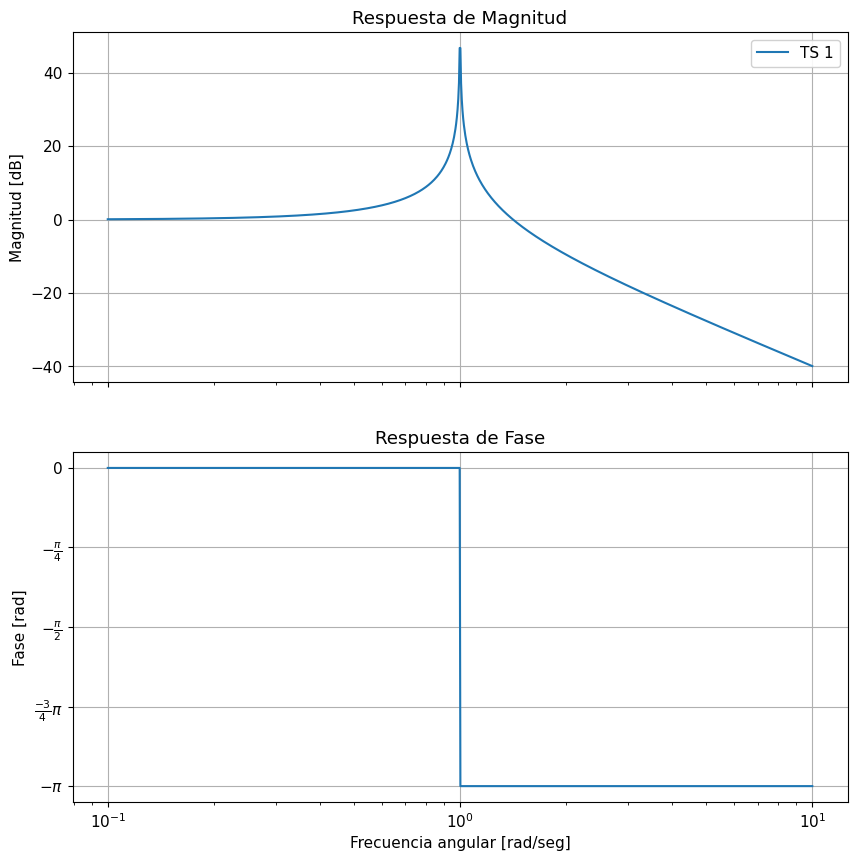

In [7]:
w0 = 1

num = np.array([ w0**2 ])
den = np.array([ 1, 0, w0**2])

H1 = sig.TransferFunction( num, den )

graficar_bode_avanzado(H1)

### 2. Transferencia $\frac{V_{21}}{V_{31}}$

* **Entrada:** entre nodo 3 y nodo 1 ($V_{31} \rightarrow m=3, n=1$).
* **Salida:** entre nodo 2 y nodo 1 ($V_{21} \rightarrow j=2, k=1$).

#### Denominador: Cofactor $Y_{31}^{31}$

Eliminando filas (1, 3) y columnas (1, 3) de $Y_{4\times 4}$:

$$Y_{31}^{31} = (-1)^{(3+1+3+1)} \det \begin{pmatrix}
Y_L & -Y_L \\
-Y_L & 2Y_L + Y_C
\end{pmatrix} = 1 \cdot [Y_L \cdot (2Y_L + Y_C) - (-Y_L) \cdot (-Y_L)] = 2Y_L^2 + Y_L \cdot Y_C - Y_L^2 = Y_L^2 + Y_L \cdot Y_C$$

#### Numerador: Cofactor $Y_{31}^{21}$

Eliminando filas (1, 2) y columnas (1, 3) de $Y_{4\times 4}$:

$$Y_{31}^{21} = (-1)^{(2+1+3+1)} \det \begin{pmatrix}
0 & -Y_C \\
-Y_L & 2Y_L + Y_C
\end{pmatrix} = (-1)^7 \cdot [0 - (-Y_C) \cdot (-Y_L)] = -1 \cdot (-Y_C \cdot Y_L) = Y_C \cdot Y_L$$

#### Transferencia final:

$$\frac{V_{21}}{V_{31}} = \frac{Y_{31}^{21}}{Y_{31}^{31}} = \frac{Y_C \cdot Y_L}{Y_L^2 + Y_L \cdot Y_C} = \frac{\cancel{Y_L} \cdot Y_C}{\cancel{Y_L} (Y_L + Y_C)} = \frac{Y_C}{Y_L + Y_C}$$

#### Resolviendo con los componentes de cada admitancia:

$$\frac{V_{21}}{V_{31}} = \frac{sC}{\frac{1}{sL} + sC} = \frac{s^2 LC}{s^2 LC + 1} = \frac{s^2}{s^2 + \frac{1}{LC}}$$

Procedemos a verificar nuestra transferencia mediante python.

In [22]:
print('Transferencia de tensión:')
Vmai = calc_MAI_vtransf_ij_mn(Ymai, 1, 0, 2, 0, verbose=con_detalles)
print_latex( r'T^{{ {:d}{:d} }}_{{ {:d}{:d} }} = '.format(2, 1, 3, 1) +  sp.latex(Vmai))

Transferencia de tensión:


<IPython.core.display.Math object>

### Simulacion de la transferencia

Empezamos por normalizar nuestra transferencia donde definimos a $\omega_0^2 = \frac{1}{LC} = 1$.

$$
T_{31}^{21} = \frac{s^2}{s^2 + \omega_0^2} = \frac{s^2}{s^2 + 1}
$$

Ya con nuestra transferencia normalizada procedemos a simularla.

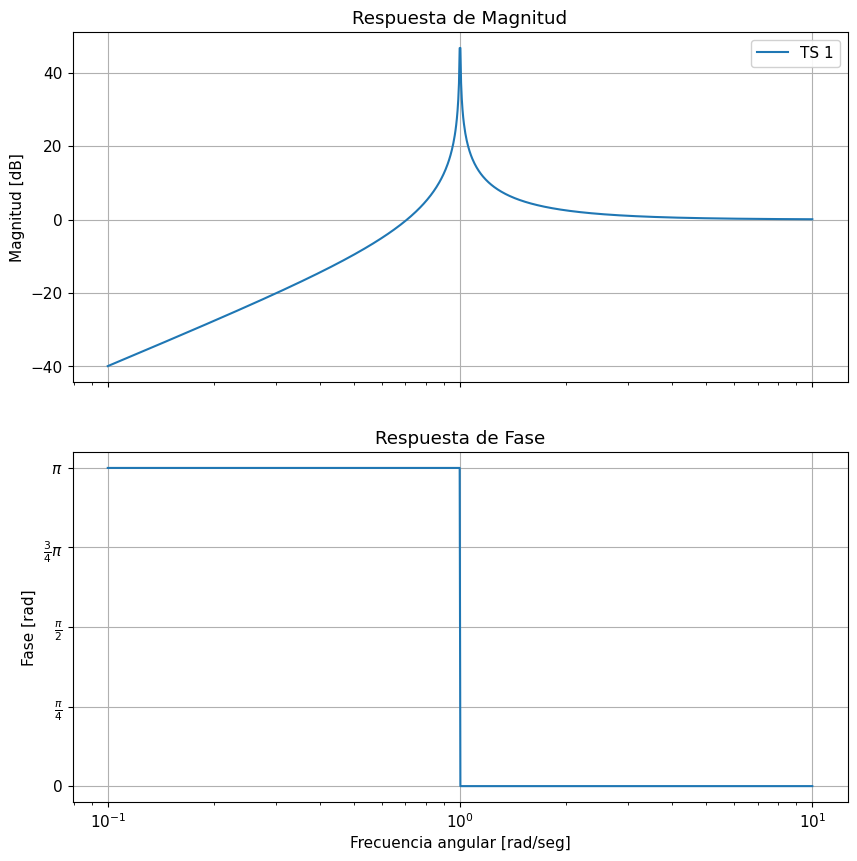

In [36]:
w0 = 1

num = np.array([ 1, 0, 0])
den = np.array([ 1, 0, w0**2])

H1 = sig.TransferFunction( num, den )

graficar_bode_avanzado(H1)

### 3. Transferencia $\frac{V_{12}}{V_{32}}$

* **Entrada:** entre nodo 3 y nodo 2 ($V_{32} \rightarrow m=3, n=2$).
* **Salida:** entre nodo 1 y nodo 2 ($V_{12} \rightarrow j=1, k=2$).

#### Denominador: Cofactor $Y_{32}^{32}$

Eliminando filas (2, 3) y columnas (2, 3) de $Y_{4\times 4}$:

$$Y_{32}^{32} = (-1)^{(3+2+3+2)} \det \begin{pmatrix}
Y_L & -Y_L \\
-Y_L & 2Y_L + Y_C
\end{pmatrix} = 1 \cdot [Y_L \cdot (2Y_L + Y_C) - (-Y_L) \cdot (-Y_L)] = 2Y_L^2 + Y_L \cdot Y_C - Y_L^2 = Y_L^2 + Y_L \cdot Y_C$$

#### Numerador: Cofactor $Y_{32}^{12}$

Eliminando filas (1, 2) y columnas (2, 3) de $Y_{4\times 4}$:

$$Y_{32}^{12} = (-1)^{(1+2+3+2)} \det \begin{pmatrix}
0 & -Y_C \\
-Y_L & 2Y_L + Y_C
\end{pmatrix} = (-1)^8 \cdot [0 - (-Y_C) \cdot (-Y_L)] = -1 \cdot Y_C \cdot Y_L = - Y_C \cdot Y_L$$

#### Transferencia final:

$$\frac{V_{12}}{V_{32}} = -\frac{Y_{32}^{12}}{Y_{32}^{32}} = -\frac{Y_C \cdot Y_L}{Y_L^2 + Y_L \cdot Y_C} = -\frac{\cancel{Y_L} \cdot Y_C}{\cancel{Y_L} (Y_L + Y_C)} = -\frac{Y_C}{Y_L + Y_C}$$

Aqui usamos la otra funcion de correccion de signo:

$$
s^* = sgn(1 - 2) \cdot sgn(3 - 2) = -1 \cdot -1 = 1
$$

Por lo que nuestra funcion de transfefrencia queda de la siguiente forma:

$$\frac{V_{12}}{V_{32}} = -s^*\frac{Y_C}{Y_L + Y_C} = - \cdot (-1)\frac{Y_C}{Y_L + Y_C} = \frac{Y_C}{Y_L + Y_C}$$

#### Resolviendo con los componentes de cada admitancia:

$$\frac{V_{12}}{V_{32}} = \frac{sC}{\frac{1}{sL} + sC} = \frac{s^2 LC}{s^2 LC + 1} = \frac{s^2}{s^2 + \frac{1}{LC}}$$

Procedemos a verificar nuestra transferencia con python.

In [25]:
print('Transferencia de tensión:')
Vmai = calc_MAI_vtransf_ij_mn(Ymai, 0, 1, 2, 1, verbose=con_detalles)
print_latex( r'T^{{ {:d}{:d} }}_{{ {:d}{:d} }} = '.format(1, 2, 3, 2) +  sp.latex(Vmai))

Transferencia de tensión:


<IPython.core.display.Math object>

### Simulacion de la transferencia

Empezamos por normalizar nuestra transferencia donde definimos a $\omega_0^2 = \frac{1}{LC} = 1$.

$$
T_{32}^{12} = \frac{s^2}{s^2 + \omega_0^2} = \frac{s^2}{s^2 + 1}
$$

Ya con nuestra transferencia normalizada procedemos a simularla.

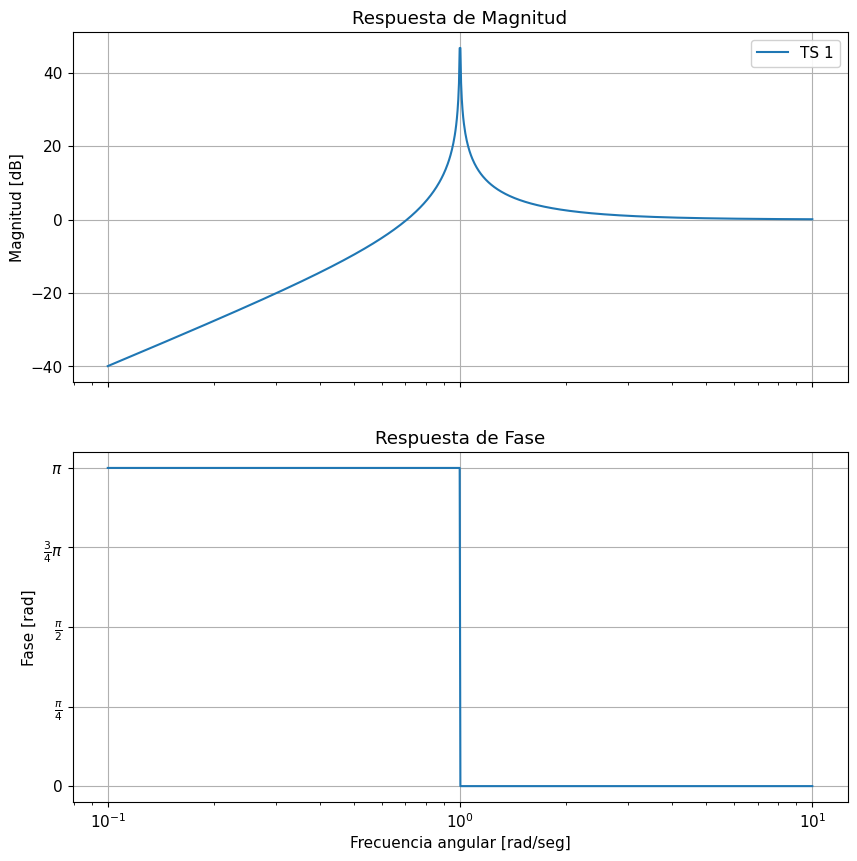

In [40]:
w0 = 1

num = np.array([ 1, 0, 0])
den = np.array([ 1, 0, w0**2])

H1 = sig.TransferFunction( num, den )

graficar_bode_avanzado(H1)

### Analisis de las transferencias obtenidas

Podemos notar visualmente que entre $T_{13}^{23}$ y $T_{32}^{12}$ son funciones complementarias y asi como tambien entre $T_{31}^{21}$ y $T_{13}^{23}$, asi que procedemos a realizar la verificacion sumando las transferencias de ambas.

$$
H(s) = T_{13}^{23} + T_{32}^{12} = \frac{s^2}{s^2 + 1} + \frac{1}{s^2 + 1} = \frac{\cancel{s^2 + 1}}{\cancel{s^2 + 1}} = 1
$$

Como podemos notar la suma de estas 2 tranferencias nos da 1.

### Analisis del MOSFET

# <img src="./cuadripolo_MOSFET_ts6.png" /> 

En la hoja de datos de los MOSFETs, las capacitancias se especifican mediante las capacitancias de entrada, salida y transferencia en cortocircuito:

* **Capacitancia de transferencia inversa:** $C_{rss} = C_{GD} \implies \mathbf{C_{GD} = C_{rss}}$
* **Capacitancia de entrada (Source común):** $C_{iss} = C_{GS} + C_{GD} \implies \mathbf{C_{GS} = C_{iss} - C_{rss}}$
* **Capacitancia de salida (Source común):** $C_{oss} = C_{DS} + C_{GD} \implies \mathbf{C_{DS} = C_{oss} - C_{rss}}$

Definimos las admitancias individuales de cada elemento pasivo en el dominio de Laplace ($s = j\omega$):
* $Y_{GS} = s C_{GS} = s(C_{iss} - C_{rss})$
* $Y_{GD} = s C_{GD} = s C_{rss}$
* $Y_{DS} = s C_{DS} = s(C_{oss} - C_{rss})$

### Matriz Admitancia Indefinida (MAI) del MOSFET

Asignamos la siguiente numeración a los nodos del transistor:

* **Nodo 1:** Gate (G)
* **Nodo 2:** Drain (D)
* **Nodo 3:** Source (S)

Ya asignado los nodos procedemos a calcular nuestra MAI.

**Fila 1 (Nodo Gate):**
   * $Y_{11}$ (Admitancia conectada a G): $Y_{GS} + Y_{GD} = s(C_{GS} + C_{GD}) = \mathbf{s C_{iss}}$
   * $Y_{12}$ (Entre G y D): $-Y_{GD} = \mathbf{-s C_{rss}}$
   * $Y_{13}$ (Entre G y S): $-Y_{GS} = \mathbf{-s (C_{iss} - C_{rss})}$

**Fila 2 (Nodo Drain):**
   * Corriente generada por la fuente dependiente: $i_D = g_m v_{gs} = g_m (v_1 - v_3)$
   * $Y_{21}$ (Efecto de $v_1$ en D): $-Y_{GD} + g_m = \mathbf{g_m - s C_{rss}}$
   * $Y_{22}$ (Admitancia conectada a D): $Y_{GD} + Y_{DS} = s(C_{GD} + C_{DS}) = \mathbf{s C_{oss}}$
   * $Y_{23}$ (Efecto de $v_3$ en D): $-Y_{DS} - g_m = \mathbf{-(g_m + s(C_{oss} - C_{rss}))}$

**Fila 3 (Nodo Source):**
   * Obtenida por propiedad de suma cero en columnas:
   * $Y_{31} = -(Y_{11} + Y_{21}) = \mathbf{-(g_m + s(C_{iss} - C_{rss}))}$
   * $Y_{32} = -(Y_{12} + Y_{22}) = s C_{rss} - s C_{oss} = \mathbf{-s (C_{oss} - C_{rss})}$
   * $Y_{33} = -(Y_{13} + Y_{23}) = \mathbf{g_m + s (C_{iss} + C_{oss} - 2C_{rss})}$

Ya establecida nuestras ecuaciones de cada nodo podemos plantear la matriz.

$$\mathbf{Y_{IND}} = \begin{bmatrix} s C_{iss} & -s C_{rss} & -s(C_{iss} - C_{rss}) \\ g_m - s C_{rss} & s C_{oss} & -(g_m + s(C_{oss} - C_{rss})) \\ -(g_m + s(C_{iss} - C_{rss})) & -s(C_{oss} - C_{rss}) & g_m + s(C_{iss} + C_{oss} - 2C_{rss}) \end{bmatrix}$$

### Parámetros para el MOS

Para obtener la matriz de dos puertos a partir de la MAI, se elimina la fila y la columna correspondiente al nodo de referencia.

#### Configuración **Source Común** (Nodo 3 de referencia: suprimir fila 3 y columna 3):
* **Entrada:** Nodo 1 (Gate)
* **Salida:** Nodo 2 (Drain)

$$\mathbf{Y_{SC}} = \begin{bmatrix} Y_{11} & Y_{12} \\ Y_{21} & Y_{22} \end{bmatrix} = \begin{bmatrix} s C_{iss} & -s C_{rss} \\ g_m - s C_{rss} & s C_{oss} \end{bmatrix}$$

#### Configuración **Drain Común** (Nodo 2 de referencia: suprimir fila 2 y columna 2):
* **Entrada:** Nodo 1 (Gate)
* **Salida:** Nodo 3 (Source)

$$\mathbf{Y_{DC}} = \begin{bmatrix} Y_{11} & Y_{13} \\ Y_{31} & Y_{33} \end{bmatrix} = \begin{bmatrix} s C_{iss} & -s(C_{iss} - C_{rss}) \\ -(g_m + s(C_{iss} - C_{rss})) & g_m + s(C_{iss} + C_{oss} - 2C_{rss}) \end{bmatrix}$$

### Matriz de Parámetros $ABCD$ en configuración Source Común

Las ecuaciones de la red de dos puertos en parámetros $ABCD$ se definen como:

$$\begin{bmatrix} V_1 \\ I_1 \end{bmatrix} = \begin{bmatrix} A & B \\ C & D \end{bmatrix} \begin{bmatrix} V_2 \\ -I_2 \end{bmatrix}$$

Utilizando las relaciones de conversión directas desde los parámetros $Y$ de Source Común ($\mathbf{Y_{SC}}$):

* **$A = -\frac{y_{22}}{y_{21}}$:**
  $$A = -\frac{s C_{oss}}{g_m - s C_{rss}} = \mathbf{\frac{s C_{oss}}{s C_{rss} - g_m}}$$

* **$B = -\frac{1}{y_{21}}$:**
  $$B = -\frac{1}{g_m - s C_{rss}} = \mathbf{\frac{1}{s C_{rss} - g_m}}$$

* **$C = -\frac{\det(Y_{SC})}{y_{21}}$:**
  Primero hallamos el determinante:
  $$\det(Y_{SC}) = y_{11} y_{22} - y_{12} y_{21} = (s C_{iss})(s C_{oss}) - (-s C_{rss})(g_m - s C_{rss})$$
  $$\det(Y_{SC}) = s^2 C_{iss} C_{oss} + s C_{rss} g_m - s^2 C_{rss}^2 = s \left[ g_m C_{rss} + s (C_{iss} C_{oss} - C_{rss}^2) \right]$$

  Dividiendo por $-y_{21}$:
  $$C = \mathbf{\frac{s \left[ g_m C_{rss} + s (C_{iss} C_{oss} - C_{rss}^2) \right]}{s C_{rss} - g_m}}$$

* **$D = -\frac{y_{11}}{y_{21}}$:**
  $$D = -\frac{s C_{iss}}{g_m - s C_{rss}} = \mathbf{\frac{s C_{iss}}{s C_{rss} - g_m}}$$

### Matriz de Transmisión $ABCD$ final:

$$\mathbf{T_{SC}} = \frac{1}{s C_{rss} - g_m} \begin{bmatrix} s C_{oss} & 1 \\ s \left[ g_m C_{rss} + s(C_{iss} C_{oss} - C_{rss}^2) \right] & s C_{iss} \end{bmatrix}$$